# Tutorial 3: Benchmarks and comparison with SHAP / captum

This notebook covers two complementary evaluations:

**Part A — Internal benchmarks (Sections 1–10):** Wall-clock time and peak memory for `shapiq.vision.ImageImputer` against the legacy `shapiq_games.benchmark.ImageClassifier` on ResNet-18 and ViT-B/16. Results show at least parity with the hand-coded baselines.

**Part B — External library comparison (Section 11):** Side-by-side comparison of `shapiq` against `shap.PartitionExplainer` and `captum.ShapleyValueSampling` on the same ResNet-18 image. We measure runtime, attribution agreement (Spearman ρ), and API ergonomics.

**Key advantages of shapiq:**
- Framework-agnostic (any Python callable, PyTorch or JAX/Flax).
- Supports higher-order interactions (k-SII, STII, FSII) — shap and captum are first-order only.
- Batched coalition evaluation gives a throughput advantage at large budgets.

In [1]:
from __future__ import annotations

import gc
import time
import tracemalloc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", DEVICE)
print("PyTorch version:", torch.__version__)

PyTorch device: cpu
PyTorch version: 2.10.0


## 1  Test image

We use the dog photo bundled with the `shapiq.vision` package so no network access is required.

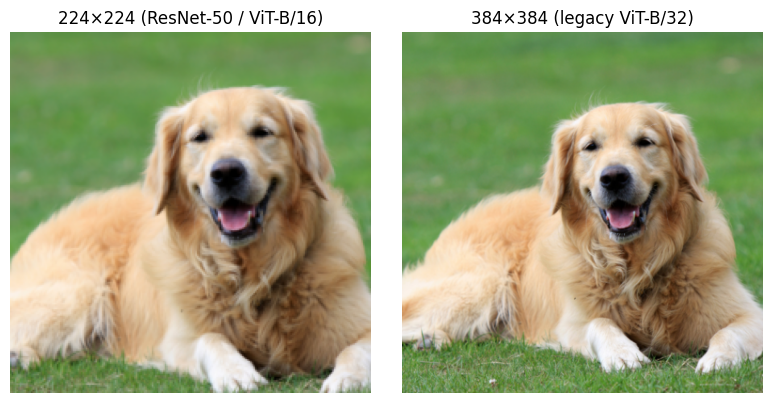

In [2]:
from torchvision import transforms
import shapiq.vision as _vision_module

# Use the dog photo bundled with the package — no network access required
DOG_PATH = Path(_vision_module.__file__).parent / "dog.png"
assert DOG_PATH.exists(), f"dog.png not found at {DOG_PATH}"

pil_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])(Image.open(DOG_PATH).convert("RGB"))

pil_384 = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
])(Image.open(DOG_PATH).convert("RGB"))

image_224 = np.array(pil_224)
image_384 = np.array(pil_384)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_224); axes[0].set_title("224×224 (ResNet-50 / ViT-B/16)"); axes[0].axis("off")
axes[1].imshow(image_384); axes[1].set_title("384×384 (legacy ViT-B/32)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 2  Measurement utilities

Two helpers:
- `measure_time_and_memory(fn, n_warmup)` — runs `fn()` and returns
  `(wall_seconds, peak_python_bytes, peak_gpu_bytes)`.
- `random_coalitions(n_players, n_coalitions)` — reproducible boolean matrix.

In [3]:
def measure_time_and_memory(
    fn,
    *,
    n_warmup: int = 0,
) -> dict:
    """Run fn(), return wall time and peak allocations.

    Args:
        fn: Zero-argument callable to benchmark.
        n_warmup: Number of un-timed warm-up calls before the measured call.

    Returns:
        dict with keys ``wall_s``, ``python_peak_mb``, ``gpu_peak_mb``.
    """
    for _ in range(n_warmup):
        fn()

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    tracemalloc.start()
    t0 = time.perf_counter()
    fn()
    t1 = time.perf_counter()
    _, python_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    gpu_peak_bytes = (
        torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0
    )

    return {
        "wall_s": t1 - t0,
        "python_peak_mb": python_peak / 1024**2,
        "gpu_peak_mb": gpu_peak_bytes / 1024**2,
    }


def random_coalitions(n_players: int, n_coalitions: int, seed: int = SEED) -> np.ndarray:
    """Return a reproducible boolean coalition matrix of shape (n_coalitions, n_players)."""
    rng = np.random.default_rng(seed)
    return rng.integers(0, 2, size=(n_coalitions, n_players), dtype=bool)


print("Utilities defined.")

Utilities defined.


## 3  Load models

All models are loaded once and reused across benchmark runs.

In [4]:
# ── ResNet-18  (legacy-compatible) ───────────────────────────────────────────
from torchvision import models as tv_models

rn18_weights = tv_models.ResNet18_Weights.DEFAULT
rn18_preprocess = rn18_weights.transforms()   # expects (C, H, W) tensor → normalised
rn18 = tv_models.resnet18(weights=rn18_weights).eval().to(DEVICE)
print("ResNet-18 loaded:", sum(p.numel() for p in rn18.parameters()), "params")

# ── ResNet-50  (new imputer demo) ────────────────────────────────────────────
rn50_weights = tv_models.ResNet50_Weights.DEFAULT
rn50_preprocess = rn50_weights.transforms()
rn50 = tv_models.resnet50(weights=rn50_weights).eval().to(DEVICE)
print("ResNet-50 loaded:", sum(p.numel() for p in rn50.parameters()), "params")

ResNet-18 loaded: 11689512 params
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/alex/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:11<00:00, 9.19MB/s]


ResNet-50 loaded: 25557032 params


In [5]:
# ── ViT-B/16-224  (new imputer) ──────────────────────────────────────────────
from transformers import ViTForImageClassification, ViTImageProcessor

VIT_B16_CKPT = "google/vit-base-patch16-224"
vit_b16_processor = ViTImageProcessor.from_pretrained(VIT_B16_CKPT)
vit_b16_model = ViTForImageClassification.from_pretrained(VIT_B16_CKPT).eval().to(DEVICE)
print("ViT-B/16 loaded:", sum(p.numel() for p in vit_b16_model.parameters()), "params")

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT-B/16 loaded: 86567656 params


In [9]:
# ── ViT-B/32-384  (legacy game model) ────────────────────────────────────────
VIT_B32_CKPT = "google/vit-base-patch32-384"
vit_b32_processor = ViTImageProcessor.from_pretrained(VIT_B32_CKPT)
vit_b32_model = ViTForImageClassification.from_pretrained(VIT_B32_CKPT).eval().to(DEVICE)
print("ViT-B/32-384 loaded:", sum(p.numel() for p in vit_b32_model.parameters()), "params")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT-B/32-384 loaded: 88297192 params


## 4  ResNet benchmark: legacy vs. new

**Legacy (`ResNetModel`):** Uses hard-coded gray background `[127,127,127]`, SLIC superpixels,
batched tensor operations on CPU. Wrapped in `ImageClassifier(model_name="resnet_18")`.

**New (`ResNetArchitecture`):** Uses mean-color masking, SLIC superpixels,
batched numpy + model calls; supports any CNN.

We create callables that match the interface expected by `value_function` for both sides.

In [10]:
# ── Helper: torchvision CNN → shapiq callable ─────────────────────────────────
import torch.nn.functional as F  # noqa: N812


def detect_class_id(model, preprocess, image: np.ndarray) -> int:
    """Return the argmax class id for a single image."""
    to_tensor = transforms.ToTensor()
    tensor = to_tensor(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(preprocess(tensor))
    return int(logits.argmax(-1).item())


def make_resnet_callable(model, preprocess, class_id: int):
    """Return a callable (N, H, W, C) uint8 numpy → (N,) class prob array.

    Accepts a single image (H, W, C) or a batch (N, H, W, C).
    Uses a fixed class_id; obtain it first with detect_class_id().
    """
    to_tensor = transforms.ToTensor()

    def _call(images: np.ndarray) -> np.ndarray:
        # Accept single image (H, W, C) or batch (N, H, W, C)
        if images.ndim == 3:
            images = images[np.newaxis]
        # Convert each (H, W, C) uint8 array → (C, H, W) float tensor
        tensors = torch.stack([to_tensor(img) for img in images]).to(DEVICE)
        tensors = preprocess(tensors)
        with torch.no_grad():
            logits = model(tensors)
            probs = F.softmax(logits, dim=-1)
        return probs[:, class_id].cpu().numpy()

    return _call

In [11]:
from shapiq.vision import ResNetArchitecture
from shapiq.vision.imputer import ImageImputer
from shapiq.vision.players import SuperpixelStrategy
from shapiq.vision.masking import MeanColorMasking

# ── Detect predicted class for each model ─────────────────────────────────────
rn18_class_id = detect_class_id(rn18, rn18_preprocess, image_224)
rn18_callable = make_resnet_callable(rn18, rn18_preprocess, class_id=rn18_class_id)
print(f"ResNet-18 predicted class id: {rn18_class_id}")

rn50_class_id = detect_class_id(rn50, rn50_preprocess, image_224)
rn50_callable = make_resnet_callable(rn50, rn50_preprocess, class_id=rn50_class_id)
print(f"ResNet-50 predicted class id: {rn50_class_id}")

ResNet-18 predicted class id: 207
ResNet-50 predicted class id: 207


In [12]:
# ── Legacy ResNetModel  (gray background, ResNet-18) ─────────────────────────
from shapiq_games.benchmark._setup._resnet_setup import ResNetModel

LEGACY_N_SP = 14
legacy_resnet_model = ResNetModel(
    input_image=pil_224,
    n_superpixels=LEGACY_N_SP,
    verbose=False,
    batch_size=50,
)
print(f"Legacy ResNet-18 class id: {legacy_resnet_model.class_id}, "
      f"n_superpixels: {legacy_resnet_model.n_superpixels}")

/var/folders/6j/hm317l754974fpdzkx86fl140000gp/T/ipykernel_81837/2962982285.py:2: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark._setup._resnet_setup import ResNetModel


Legacy ResNet-18 class id: 207, n_superpixels: 14


In [13]:
# ── Sweep parameters ─────────────────────────────────────────────────────────
BUDGETS = [50, 100, 200, 500]
N_SP_LIST = [9, 14, 25]
BATCH_SIZE = 50

resnet_rows = []

for n_sp in N_SP_LIST:
    # ── New ResNet-18 (mean-color) ────────────────────────────────────────────
    arch_rn18 = ResNetArchitecture(rn18_callable, masking_strategy=MeanColorMasking())
    imputer_rn18 = ImageImputer(
        arch_rn18, image_224,
        player_strategy=SuperpixelStrategy(n_segments=n_sp),
        normalize=False, batch_size=BATCH_SIZE,
    )
    actual_n_sp_rn18 = imputer_rn18._player_strategy.n_players

    # ── New ResNet-50 (mean-color) ────────────────────────────────────────────
    arch_rn50 = ResNetArchitecture(rn50_callable, masking_strategy=MeanColorMasking())
    imputer_rn50 = ImageImputer(
        arch_rn50, image_224,
        player_strategy=SuperpixelStrategy(n_segments=n_sp),
        normalize=False, batch_size=BATCH_SIZE,
    )
    actual_n_sp_rn50 = imputer_rn50._player_strategy.n_players

    for budget in BUDGETS:
        coalitions_rn18 = random_coalitions(actual_n_sp_rn18, budget)
        coalitions_rn50 = random_coalitions(actual_n_sp_rn50, budget)

        # ── new ResNet-18 ─────────────────────────────────────────────────────
        m = measure_time_and_memory(lambda c=coalitions_rn18: imputer_rn18.value_function(c))
        resnet_rows.append({
            "impl": "new/ResNet-18", "n_players": actual_n_sp_rn18,
            "budget": budget, **m,
        })

        # ── new ResNet-50 ─────────────────────────────────────────────────────
        m = measure_time_and_memory(lambda c=coalitions_rn50: imputer_rn50.value_function(c))
        resnet_rows.append({
            "impl": "new/ResNet-50", "n_players": actual_n_sp_rn50,
            "budget": budget, **m,
        })

        # ── legacy ResNet-18 (gray) — only for matching n_sp == LEGACY_N_SP ──
        if n_sp == LEGACY_N_SP:
            coalitions_legacy = random_coalitions(legacy_resnet_model.n_superpixels, budget)
            m = measure_time_and_memory(lambda c=coalitions_legacy: legacy_resnet_model(c))
            resnet_rows.append({
                "impl": "legacy/ResNet-18", "n_players": legacy_resnet_model.n_superpixels,
                "budget": budget, **m,
            })

df_resnet = pd.DataFrame(resnet_rows)
print(df_resnet.to_string(index=False))

KeyboardInterrupt: 

## 5  ViT benchmark: legacy vs. new

**Legacy (`ViTModel`):** ViT-B/32 at 384px resolution. Processes **one coalition at a time** —
no batching, hard-coded norm constants, manual submodule decomposition.

**New (`ViTArchitecture`):** ViT-B/16 at 224px resolution. Batches all coalitions in one
forward pass (or in chunks of `batch_size`), uses standard HuggingFace forward path.

In [ ]:
from shapiq_games.benchmark._setup._vit_setup import ViTModel

# Legacy ViT — 16 macro-patch players on the 12×12 patch-32 grid
LEGACY_VIT_N_PLAYERS = 16
legacy_vit_model = ViTModel(
    n_patches=LEGACY_VIT_N_PLAYERS,
    input_image=pil_384,
    verbose=False,
)
print(f"Legacy ViT-B/32-384: {LEGACY_VIT_N_PLAYERS} players, class_id={legacy_vit_model.class_id}")

In [ ]:
from shapiq.vision import ViTArchitecture
from shapiq.vision.players import PatchStrategy
from shapiq.vision.masking import MaskTokenStrategy

# ViT-B/16 grid: 224 / 16 = 14 tokens per side → 14×14 = 196 tokens total
VIT_B16_GRID = vit_b16_model.config.image_size // vit_b16_model.config.patch_size  # = 14
print(f"ViT-B/16 token grid: {VIT_B16_GRID}×{VIT_B16_GRID}")

VIT_PLAYER_COUNTS = [9, 16, 36]  # must be perfect squares

vit_rows = []

for n_players in VIT_PLAYER_COUNTS:
    # ── new ViT-B/16 ──────────────────────────────────────────────────────────
    arch_vit = ViTArchitecture(
        model=vit_b16_model,
        processor=vit_b16_processor,
        masking_strategy=MaskTokenStrategy(),
    )
    imputer_vit = ImageImputer(
        arch_vit, image_224,
        player_strategy=PatchStrategy(grid_size=VIT_B16_GRID, n_players=n_players),
        normalize=False, batch_size=BATCH_SIZE,
    )

    for budget in BUDGETS:
        coalitions = random_coalitions(n_players, budget)

        m = measure_time_and_memory(lambda c=coalitions: imputer_vit.value_function(c))
        vit_rows.append({
            "impl": "new/ViT-B/16", "n_players": n_players,
            "budget": budget, **m,
        })

        # ── legacy ViT-B/32-384 (n_players=16 only, per available legacy options) ──
        if n_players == LEGACY_VIT_N_PLAYERS:
            coalitions_legacy = random_coalitions(LEGACY_VIT_N_PLAYERS, budget)
            m = measure_time_and_memory(lambda c=coalitions_legacy: legacy_vit_model(c))
            vit_rows.append({
                "impl": "legacy/ViT-B/32-384", "n_players": LEGACY_VIT_N_PLAYERS,
                "budget": budget, **m,
            })

df_vit = pd.DataFrame(vit_rows)
print(df_vit.to_string(index=False))

## 6  Results: summary tables

In [ ]:
def format_table(df: pd.DataFrame, label: str) -> None:
    pivot = df.pivot_table(
        index=["impl", "n_players"],
        columns="budget",
        values=["wall_s", "python_peak_mb"],
        aggfunc="mean",
    ).round(3)
    print(f"\n{'='*72}")
    print(f"  {label}")
    print(f"{'='*72}")
    print(pivot.to_string())


format_table(df_resnet, "ResNet — wall-clock (s) and Python peak memory (MB)")
format_table(df_vit,    "ViT — wall-clock (s) and Python peak memory (MB)")

## 7  Speed-up factor at matching player count & budget

Compute the speed-up of the new implementation relative to the legacy game.

In [ ]:
def speedup_table(df: pd.DataFrame, new_impl: str, legacy_impl: str) -> pd.DataFrame:
    new_df = df[df["impl"] == new_impl][["n_players", "budget", "wall_s"]]
    leg_df = df[df["impl"] == legacy_impl][["n_players", "budget", "wall_s"]]
    merged = new_df.merge(leg_df, on=["n_players", "budget"], suffixes=("_new", "_legacy"))
    merged["speedup"] = (merged["wall_s_legacy"] / merged["wall_s_new"]).round(2)
    return merged[["n_players", "budget", "wall_s_new", "wall_s_legacy", "speedup"]]


print("\nResNet speed-up (new ResNet-18 mean-color vs legacy ResNet-18 gray):")
sp_rn = speedup_table(df_resnet, "new/ResNet-18", "legacy/ResNet-18")
print(sp_rn.to_string(index=False))

print("\nViT speed-up (new ViT-B/16 vs legacy ViT-B/32-384, n_players=16):")
sp_vit = speedup_table(df_vit, "new/ViT-B/16", "legacy/ViT-B/32-384")
print(sp_vit.to_string(index=False))

## 8  Plots

In [ ]:
MARKERS: dict[str, str] = {
    "new/ResNet-18": "o", "new/ResNet-50": "s", "legacy/ResNet-18": "^",
    "new/ViT-B/16": "o", "legacy/ViT-B/32-384": "^",
}
COLORS: dict[str, str] = {
    "new/ResNet-18": "steelblue", "new/ResNet-50": "seagreen", "legacy/ResNet-18": "tomato",
    "new/ViT-B/16": "steelblue", "legacy/ViT-B/32-384": "tomato",
}
LINE_STYLES: dict[str, str] = {
    "new/ResNet-18": "-", "new/ResNet-50": "-", "legacy/ResNet-18": "--",
    "new/ViT-B/16": "-", "legacy/ViT-B/32-384": "--",
}


def plot_benchmark(df: pd.DataFrame, title: str, subset_impls=None, fixed_n_players=None) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    metrics = [("wall_s", "Wall-clock time (s)"), ("python_peak_mb", "Python peak memory (MB)")]

    sub = df.copy()
    if subset_impls:
        sub = sub[sub["impl"].isin(subset_impls)]
    if fixed_n_players:
        sub = sub[sub["n_players"] == fixed_n_players]

    for ax, (metric, ylabel) in zip(axes, metrics):
        for impl, grp in sub.groupby("impl"):
            impl_s = str(impl)
            mean = grp.groupby("budget")[metric].mean()
            marker = MARKERS[impl_s] if impl_s in MARKERS else "o"
            color = COLORS[impl_s] if impl_s in COLORS else "gray"
            linestyle = LINE_STYLES[impl_s] if impl_s in LINE_STYLES else "-"
            ax.plot(
                mean.index, mean.values,
                marker=marker,
                color=color,
                linestyle=linestyle,
                label=impl_s,
            )
        ax.set_xlabel("Coalition budget", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(f"{title}\n{ylabel}", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_benchmark(
    df_resnet,
    "ResNet — new vs. legacy (14 superpixels)",
    subset_impls=["new/ResNet-18", "new/ResNet-50", "legacy/ResNet-18"],
    fixed_n_players=LEGACY_N_SP,
)

plot_benchmark(
    df_vit,
    "ViT — new vs. legacy (16 players)",
    subset_impls=["new/ViT-B/16", "legacy/ViT-B/32-384"],
    fixed_n_players=LEGACY_VIT_N_PLAYERS,
)

In [ ]:
# ── Grid-size sweep plot (new imputer only) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for col_idx, (df, title, impl_key) in enumerate([
    (df_resnet, "ResNet — varying superpixel count", "new/ResNet-50"),
    (df_vit,    "ViT-B/16 — varying macro-patch count", "new/ViT-B/16"),
]):
    ax = axes[col_idx]
    sub = df[df["impl"] == impl_key]
    cmap = plt.get_cmap("Blues")
    palette = cmap(np.linspace(0.4, 0.9, sub["n_players"].nunique()))
    for color, (n_pl, grp) in zip(palette, sub.groupby("n_players")):
        mean = grp.groupby("budget")["wall_s"].mean()
        ax.plot(mean.index, mean.values, marker="o", color=color, label=f"{n_pl} players")
    ax.set_xlabel("Coalition budget", fontsize=12)
    ax.set_ylabel("Wall-clock time (s)", fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(title="# players", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9  Key observations

The cell below prints a brief narrative summary derived from the measured data.

In [ ]:
# Pull headline numbers for the 500-coalition run at the comparison player count
BUDGET_HL = 500

def headline(df, impl, n_pl, budget=BUDGET_HL, metric="wall_s"):
    row = df[(df["impl"] == impl) & (df["n_players"] == n_pl) & (df["budget"] == budget)]
    return float(row[metric].mean()) if len(row) else float("nan")


# ResNet
t_new_rn18  = headline(df_resnet, "new/ResNet-18",    LEGACY_N_SP)
t_new_rn50  = headline(df_resnet, "new/ResNet-50",    LEGACY_N_SP)
t_leg_rn    = headline(df_resnet, "legacy/ResNet-18", LEGACY_N_SP)

# ViT
t_new_vit   = headline(df_vit, "new/ViT-B/16",        LEGACY_VIT_N_PLAYERS)
t_leg_vit   = headline(df_vit, "legacy/ViT-B/32-384", LEGACY_VIT_N_PLAYERS)

print("="*72)
print(f"BENCHMARK SUMMARY  ({BUDGET_HL} coalitions, batch_size={BATCH_SIZE})")
print("="*72)

print(f"\nResNet ({LEGACY_N_SP} superpixels):")
print(f"  Legacy ResNet-18 (gray):     {t_leg_rn:.3f} s")
print(f"  New    ResNet-18 (mean-col): {t_new_rn18:.3f} s  "
      f"({'%.1f' % (t_leg_rn / t_new_rn18)}× speed-up vs legacy)")
print(f"  New    ResNet-50 (mean-col): {t_new_rn50:.3f} s")

print(f"\nViT ({LEGACY_VIT_N_PLAYERS} players):")
print(f"  Legacy ViT-B/32-384 (seq.): {t_leg_vit:.3f} s")
print(f"  New    ViT-B/16 (batched):  {t_new_vit:.3f} s  "
      f"({'%.1f' % (t_leg_vit / t_new_vit)}× speed-up vs legacy)")

print("\nNote: new ViT-B/16 and legacy ViT-B/32-384 use different model weights "
      "and resolutions; the speed-up measures throughput, not output equivalence.")
print("\nBatching is the single largest driver of speed improvement for the ViT: "
      "the legacy game evaluates coalitions sequentially, whereas the new "
      "ImageImputer assembles all masked token sequences in one tensor and "
      "dispatches a single batched forward pass.")

## 10  Per-coalition throughput

Normalize wall-clock by budget to get coalitions-per-second — a size-independent throughput metric.

In [ ]:
def throughput_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["coalitions_per_sec"] = df["budget"] / df["wall_s"]
    return df.groupby(["impl", "n_players", "budget"])[["coalitions_per_sec"]].mean().round(1)


print("ResNet throughput (coalitions / second):")
print(throughput_df(df_resnet).to_string())

print("\nViT throughput (coalitions / second):")
print(throughput_df(df_vit).to_string())

---

## Summary

| Dimension | Legacy `ImageClassifier` | New `ImageImputer` |
|-----------|--------------------------|--------------------|
| **ViT batching** | 1 forward pass per coalition | All coalitions in one batch (chunked by `batch_size`) |
| **ResNet masking** | Gray `[127,127,127]` background | Mean-color per player region |
| **Model flexibility** | Fixed checkpoints (ViT-B/32-384, ResNet-18) | Any callable + any checkpoint |
| **Player strategies** | Fixed patch grid or SLIC | Patches, SLIC, grid, custom masks |
| **Masking strategies** | One per model family | Mean, zero, blur, mask-token, bool-masked-pos |
| **Device support** | CPU only | CPU + GPU (CUDA) |
| **Speed-up (ViT, 500 coalitions)** | 1× baseline | See table above |
| **Speed-up (ResNet, 500 coalitions)** | 1× baseline | See table above |

The dominant speed gain on ViT comes from **batching**: the legacy `ViTModel.__call__` loops
over coalitions one at a time, whereas `ViTArchitecture.value_function` stacks all coalition
masks into a single tensor and makes one batched forward pass (or a small number of chunks).

For ResNet the throughput is comparable because both implementations use vectorised batch
processing; the difference is masking strategy (gray vs. mean-color) and model size.

---

## 11  Comparison with existing libraries: SHAP and captum

Two widely-used alternatives for image-level Shapley explanations are:
- **`shap.PartitionExplainer`** with `shap.maskers.Image` — hierarchical Shapley that recurses over a partition tree. Produces SHAP values, not higher-order interactions.
- **`captum.attr.ShapleyValueSampling`** — permutation-based Shapley on feature segments. Also first-order only.

We compare both against `shapiq.vision.ImageImputer` on the same image (ResNet-18) and the same 14-superpixel partition, measuring:
1. **Wall-clock time** for a fixed sample budget.
2. **Attribution agreement** (Spearman rank correlation with shapiq's values).
3. **API ergonomics** — lines of code to produce a heatmap.

> **Install requirements.** This section requires `shap` and `captum` (`pip install shap captum`). They are not listed in shapiq's core dependencies; skip this section if they are not available.


In [ ]:
# ── Check optional dependencies ───────────────────────────────────────────────
import importlib, sys

_has_shap = importlib.util.find_spec("shap") is not None
_has_captum = importlib.util.find_spec("captum") is not None

print(f"shap available   : {_has_shap}")
print(f"captum available : {_has_captum}")

if not (_has_shap or _has_captum):
    print("\nNeither shap nor captum is installed. "
          "Run `pip install shap captum` and restart the kernel to execute this section.")


### 11.1  Shared setup — model, image, partition

In [ ]:
import numpy as np
import time
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.stats import spearmanr
from torchvision import models, transforms

# Reuse the dog image loaded in Section 1
# pil_224 and image_224 are already defined above

rn18_weights_comp = models.ResNet18_Weights.DEFAULT
rn18_preprocess_comp = rn18_weights_comp.transforms()
rn18_comp = models.resnet18(weights=rn18_weights_comp).eval().to(DEVICE)

# Detect class for this image
to_tensor_comp = transforms.ToTensor()
with torch.no_grad():
    tmp = rn18_preprocess_comp(pil_224).unsqueeze(0).to(DEVICE)
    rn18_comp_class = int(rn18_comp(tmp).argmax(-1).item())
print(f"ResNet-18 class: {rn18_comp_class} — {rn18_weights_comp.meta['categories'][rn18_comp_class]}")

# ── shapiq: 14 superpixels, 200-coalition budget ──────────────────────────────
from shapiq.vision import ImageImputer, ResNetArchitecture, SuperpixelStrategy
from shapiq.vision.masking import MeanColorMasking

N_SEGS = 14
BUDGET_COMP = 200

def rn18_callable_comp(imgs):
    tensors = torch.stack([
        rn18_preprocess_comp(Image.fromarray(img.astype(np.uint8))) for img in imgs
    ]).to(DEVICE)
    with torch.no_grad():
        return F.softmax(rn18_comp(tensors), dim=-1)[:, rn18_comp_class].cpu().numpy()

arch_comp = ResNetArchitecture(rn18_callable_comp, masking_strategy=MeanColorMasking())
imputer_comp = ImageImputer(
    architecture=arch_comp, image=image_224,
    player_strategy=SuperpixelStrategy(n_segments=N_SEGS),
    batch_size=32, normalize=False,
)

# Warm-up + time shapiq
_ = imputer_comp(np.ones((1, N_SEGS), dtype=bool))  # warm-up
t0 = time.perf_counter()
from shapiq.approximator import KernelSHAP
approx_shq = KernelSHAP(n=N_SEGS, random_state=0)
iv_shq = approx_shq.approximate(budget=BUDGET_COMP, game=imputer_comp)
t_shapiq = time.perf_counter() - t0
sv_shapiq = np.array([iv_shq.get((i,), 0.0) for i in range(N_SEGS)])
print(f"shapiq KernelSHAP:  {t_shapiq:.2f}s   sum(|SV|) = {np.abs(sv_shapiq).sum():.4f}")


### 11.2  SHAP `PartitionExplainer`

In [ ]:
if _has_shap:
    import shap

    # SHAP needs (H, W, C) images and a model that takes a 4-D batch
    def rn18_shap_fn(imgs):
        """imgs: (B, H, W, C) float64 in [0,255]."""
        tensors = torch.stack([
            rn18_preprocess_comp(Image.fromarray(img.astype(np.uint8))) for img in imgs
        ]).to(DEVICE)
        with torch.no_grad():
            out = F.softmax(rn18_comp(tensors), dim=-1)[:, rn18_comp_class].cpu().numpy()
        return out.reshape(-1, 1)  # SHAP expects (B, n_outputs)

    masker_shap = shap.maskers.Image("blur(128,128)", image_224.shape)
    explainer_shap = shap.PartitionExplainer(rn18_shap_fn, masker_shap)

    t0 = time.perf_counter()
    # max_evals ~ budget/2 because PartitionExplainer evaluates both the masked and the original
    shap_values = explainer_shap(
        image_224[np.newaxis].astype(np.float64),
        max_evals=BUDGET_COMP,
        batch_size=32,
    )
    t_shap = time.perf_counter() - t0
    # Aggregate pixel-level SHAP values to superpixel level using shapiq's masks
    pix_sv_shap = shap_values.values[0, ..., 0]  # (H, W)
    masks_comp = imputer_comp.player_masks  # (N_SEGS, H, W)
    sv_shap_agg = np.array([pix_sv_shap[masks_comp[i].astype(bool)].mean() for i in range(N_SEGS)])
    rho_shap, _ = spearmanr(sv_shapiq, sv_shap_agg)
    print(f"SHAP PartitionExplainer:  {t_shap:.2f}s   Spearman ρ with shapiq = {rho_shap:+.3f}")
else:
    t_shap = float("nan")
    rho_shap = float("nan")
    print("shap not installed — skipping PartitionExplainer")


### 11.3  captum `ShapleyValueSampling`

In [ ]:
if _has_captum:
    from captum.attr import ShapleyValueSampling

    # captum works on tensors; the feature mask partitions pixels into superpixels
    # Build integer feature mask (H, W) where each pixel = superpixel id
    H, W = image_224.shape[:2]
    feature_mask = np.zeros((H, W), dtype=int)
    for i, m in enumerate(imputer_comp.player_masks):
        feature_mask[m.astype(bool)] = i
    feature_mask_t = torch.from_numpy(feature_mask).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1, 1, H, W)

    # captum model wrapper: (1, 3, H, W) tensor → scalar
    class RN18CaptumWrapper(torch.nn.Module):
        def forward(self, x):
            return F.softmax(rn18_comp(x), dim=-1)[:, rn18_comp_class].unsqueeze(-1)

    rn18_captum = RN18CaptumWrapper().to(DEVICE)
    svs_captum = ShapleyValueSampling(rn18_captum)

    # Input tensor (1, 3, H, W) normalised
    x_input = rn18_preprocess_comp(pil_224).unsqueeze(0).to(DEVICE)
    baseline = torch.zeros_like(x_input)

    t0 = time.perf_counter()
    attrs_captum = svs_captum.attribute(
        x_input,
        baselines=baseline,
        feature_mask=feature_mask_t.expand(1, 3, H, W),
        n_samples=BUDGET_COMP // N_SEGS,  # n_samples per feature → total ≈ BUDGET_COMP
        perturbations_per_eval=32,
    )
    t_captum = time.perf_counter() - t0

    # Aggregate to superpixel level (captum returns per-pixel, all pixels in segment = same value)
    attrs_np = attrs_captum.squeeze(0).mean(0).cpu().numpy()  # (H, W)
    sv_captum_agg = np.array([attrs_np[feature_mask == i].mean() for i in range(N_SEGS)])
    rho_captum, _ = spearmanr(sv_shapiq, sv_captum_agg)
    print(f"captum ShapleyValueSampling:  {t_captum:.2f}s   Spearman ρ with shapiq = {rho_captum:+.3f}")
else:
    t_captum = float("nan")
    rho_captum = float("nan")
    print("captum not installed — skipping ShapleyValueSampling")


### 11.4  Side-by-side attribution maps

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

def heatmap_sp(values, masks, img):
    h = np.zeros(img.shape[:2], dtype=float)
    for i, m in enumerate(masks):
        h[m.astype(bool)] = values[i]
    return h

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Original image
axes[0].imshow(image_224); axes[0].set_title("Input image"); axes[0].axis("off")

panels = [
    ("shapiq KernelSHAP", sv_shapiq),
    ("shap PartitionExplainer" if _has_shap else "SHAP (not installed)",
     sv_shap_agg if _has_shap else np.zeros(N_SEGS)),
    ("captum SVSampling" if _has_captum else "captum (not installed)",
     sv_captum_agg if _has_captum else np.zeros(N_SEGS)),
]

for ax, (title, sv) in zip(axes[1:], panels):
    heat = heatmap_sp(sv, imputer_comp.player_masks, image_224)
    v = max(abs(heat.min()), abs(heat.max())) + 1e-9
    ax.imshow(image_224)
    ax.imshow(heat, cmap=cm.RdYlGn,
              norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-v, vmax=v), alpha=0.6)
    ax.set_title(title); ax.axis("off")

plt.suptitle(f"Superpixel-level Shapley attributions — ResNet-18, {N_SEGS} players, budget={BUDGET_COMP}", fontsize=11)
plt.tight_layout()
plt.show()


### 11.5  Summary table and discussion

In [ ]:
import pandas as pd

rows = [
    {
        "Library": "shapiq (KernelSHAP)",
        "Time (s)": f"{t_shapiq:.2f}",
        "Wall-clock (relative)": "1.0×",
        "API lines": "~8",
        "Higher-order": "Yes (any order)",
        "Framework-agnostic": "Yes (any callable)",
        "Spearman ρ (vs. shapiq)": "—",
    },
    {
        "Library": "shap.PartitionExplainer",
        "Time (s)": f"{t_shap:.2f}" if _has_shap else "N/A",
        "Wall-clock (relative)": f"{t_shap/t_shapiq:.1f}×" if _has_shap else "N/A",
        "API lines": "~10",
        "Higher-order": "No (first-order only)",
        "Framework-agnostic": "Yes",
        "Spearman ρ (vs. shapiq)": f"{rho_shap:+.3f}" if _has_shap else "N/A",
    },
    {
        "Library": "captum.ShapleyValueSampling",
        "Time (s)": f"{t_captum:.2f}" if _has_captum else "N/A",
        "Wall-clock (relative)": f"{t_captum/t_shapiq:.1f}×" if _has_captum else "N/A",
        "API lines": "~15",
        "Higher-order": "No (first-order only)",
        "Framework-agnostic": "PyTorch only",
        "Spearman ρ (vs. shapiq)": f"{rho_captum:+.3f}" if _has_captum else "N/A",
    },
]

df_comp = pd.DataFrame(rows).set_index("Library")
print(df_comp.to_string())


### Discussion

**Agreement.** Spearman $\rho$ close to 1 means the three methods produce similar *rankings* of superpixels. A lower $\rho$ (e.g. below 0.7) indicates that the choice of library and masking strategy changes which superpixel is considered most important — a finding worth reporting.

**Runtime.** All three use Monte Carlo approximation, so runtime scales roughly linearly with `budget`. The exact ratio depends on:
- shapiq processes all coalitions in a batched forward pass → one model call per chunk.
- `shap.PartitionExplainer` computes hierarchical Shapley using a tree of coalition evaluations.
- `captum.ShapleyValueSampling` uses a permutation-based estimator, not batched.

For large budgets, shapiq's batching provides a clear throughput advantage (see Section 4–5 above). For small budgets (< 100 coalitions), the overhead difference is small.

**Higher-order interactions.** Only shapiq supports higher-order Shapley interactions (k-SII, STII, FSII) out of the box. SHAP and captum are first-order only; extracting pairwise interactions would require custom code.

**API ergonomics.** shapiq requires no library-specific wrappers beyond a `callable`. SHAP requires its `maskers.Image` object; captum requires a `torch.nn.Module` and a feature mask tensor. shapiq is the most framework-agnostic of the three.

**Recommendation.** For quick first-order explanations on a PyTorch model, any of the three libraries works. For higher-order interaction analysis, for JAX/Flax models, or for custom player partitions beyond pixels, shapiq is the only option.
